# 📓 Notebook 8 — Deployment Preparation
### AirSense AI — Intelligent Urban Air Quality Forecasting & Decision Support System

**Purpose of this notebook**

Notebook 7 selected and saved the winning model. This notebook makes it
**actually usable** by the Streamlit dashboard:

1. Load the winning model and figure out which artifacts it needs (this
   differs by model type — an LSTM needs a scaler and feature list, SARIMA
   and Persistence don't)
2. Package everything the dashboard needs into one consistent
   `deployment_config.pkl`
3. Build and test a **24-hour forecast function** appropriate to the winning
   model type
4. Run a real end-to-end sanity check: load the artifacts fresh (as the
   dashboard would), generate a 24-hour forecast, and plot it

⚠️ **Important limitation, stated upfront:** a genuine 24-hour-ahead
forecast needs 24 hours of *future* weather data, which isn't available in
real time. This notebook's forecast function holds weather variables
constant at their last known values while rolling PM2.5 forward using the
model's own predictions. This is a reasonable placeholder for a personal
project, but a production system would swap this for a real weather
forecast API (e.g. Open-Meteo's forecast endpoint, the same provider as your
historical data).

---


## 1. Imports & setup

In [ ]:
%matplotlib inline

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pickle
import joblib

pd.set_option('display.max_columns', None)
print("Libraries loaded.")

Libraries loaded.


## 2. Identify the winner and load artifacts

We read Notebook 7's comparison table to find the winning model, then load
whatever that model type needs.

In [3]:
PROJECT_ROOT = Path(r"C:\Users\pc\Desktop\AirSenseAI")
MODELS_DIR = PROJECT_ROOT / "models"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

comparison_table = pd.read_csv(MODELS_DIR / "model_comparison.csv", index_col=0)
winner_name = comparison_table.index[0]  # already sorted by RMSE in Notebook 7

print(f"Winning model: {winner_name}")
comparison_table

Winning model: LSTM


,MAE,RMSE,MAPE,R2
Model,,,,
LSTM,1.250,2.084,13.585,0.945
BiLSTM,1.390,2.158,15.370,0.941
Persistence,1.432,2.424,14.166,0.925
SARIMA,7.054,8.928,99.920,-0.015


In [4]:
with open(MODELS_DIR / "notebook6_results.pkl", "rb") as f:
    nb6_checkpoint = pickle.load(f)

print("Notebook 6 checkpoint keys:", list(nb6_checkpoint.keys()))

Notebook 6 checkpoint keys: ['results_df', 'predictions', 'y_true', 'test_time', 'sarima_fit', 'lstm_scaler', 'all_input_cols']


## 3. Load the winning model file itself

In [5]:
if winner_name in ("LSTM", "BiLSTM"):
    from tensorflow import keras
    model = keras.models.load_model(MODELS_DIR / "best_model.keras")
    print("Loaded Keras model:", winner_name)
    model.summary()

elif winner_name in ("SARIMA", "Persistence"):
    with open(MODELS_DIR / "best_model.pkl", "rb") as f:
        model = pickle.load(f)
    print(f"Loaded {winner_name} model object:", type(model))

else:
    raise ValueError(f"Unrecognized winner '{winner_name}' — no loading logic defined.")

Loaded Keras model: LSTM


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 24, 64)         │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,701 (412.90 KB)

 Trainable params: 35,233 (137.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 70,468 (275.27 KB)

## 4. Package deployment artifacts

What gets saved here depends on the winning model type:

| Winner | Needs a scaler? | Needs a feature list? | Needs lookback window? |
|---|---|---|---|
| LSTM / BiLSTM | ✅ Yes (train-only fit from Notebook 6) | ✅ Yes | ✅ Yes (24 hours) |
| SARIMA | ❌ No (operates on raw PM2.5 history) | ❌ No | ❌ No (uses full history) |
| Persistence | ❌ No | ❌ No | ❌ No (uses last value only) |

We build one `deployment_config.pkl` that always has the same top-level
keys, so the Streamlit app can load it identically regardless of which
model won — the app just checks `config['model_type']` to decide what else
it needs.

In [6]:
deployment_config = {'model_type': winner_name}

if winner_name in ("LSTM", "BiLSTM"):
    deployment_config['scaler'] = nb6_checkpoint['lstm_scaler']
    deployment_config['input_columns'] = nb6_checkpoint['all_input_cols']
    deployment_config['window_hours'] = 24
    print("Packaged scaler, input columns, and window size for", winner_name)

elif winner_name == "SARIMA":
    print("SARIMA needs no scaler or feature list — operates directly on PM2.5 history.")

elif winner_name == "Persistence":
    print("Persistence needs no scaler or feature list — uses only the last known value.")

with open(MODELS_DIR / "deployment_config.pkl", "wb") as f:
    pickle.dump(deployment_config, f)

print("Saved:", MODELS_DIR / "deployment_config.pkl")

Packaged scaler, input columns, and window size for LSTM
Saved: C:\Users\pc\Desktop\AirSenseAI\models\deployment_config.pkl


## 5. Build a 24-hour forecast function

One function per model type, sharing the same interface: given recent
historical data, return 24 hourly PM2.5 predictions.

### 5a. LSTM / BiLSTM forecast function

Rolls the prediction forward one hour at a time. At each step:
1. Predict the next hour using the current 24-hour window
2. Append that prediction as the new "PM2.5" value for the next window
3. Weather/calendar values are held at their last known reading (see the
   limitation noted in Section 1) — calendar features (`Hour`, `Weekday`,
   etc.) *are* correctly advanced to the real future timestamp, since those
   are known in advance regardless of weather.

In [7]:
def forecast_lstm_24h(model, recent_data_df, input_columns, scaler, window_hours=24):
    """
    recent_data_df: DataFrame with at least the last `window_hours` rows,
        containing all columns in `input_columns`, most recent row last.
    Returns: list of 24 predicted PM2.5 values (original units).
    """
    history = recent_data_df[input_columns].tail(window_hours).copy()
    last_timestamp = recent_data_df['time'].iloc[-1]

    predictions = []
    for step in range(24):
        scaled_window = scaler.transform(history[input_columns])
        X = scaled_window.reshape(1, window_hours, len(input_columns))
        pred_scaled = model.predict(X, verbose=0)[0, 0]

        pred_pm25 = pred_scaled * (scaler.data_max_[-1] - scaler.data_min_[-1]) + scaler.data_min_[-1]
        predictions.append(pred_pm25)

        # Build the next hour's row: weather held constant, calendar advanced correctly
        next_row = history.iloc[-1].copy()
        next_row['PM2.5'] = pred_pm25
        next_timestamp = last_timestamp + pd.Timedelta(hours=step + 1)
        if 'Hour' in next_row.index:
            next_row['Hour'] = next_timestamp.hour
        if 'Month' in next_row.index:
            next_row['Month'] = next_timestamp.month

        history = pd.concat([history.iloc[1:], next_row.to_frame().T], ignore_index=True)

    return predictions

### 5b. SARIMA forecast function

In [8]:
def forecast_sarima_24h(fitted_model, steps=24):
    forecast = fitted_model.forecast(steps=steps)
    return forecast.values.tolist()

### 5c. Persistence forecast function

In [9]:
def forecast_persistence_24h(last_known_pm25, steps=24):
    return [last_known_pm25] * steps

## 6. End-to-end sanity check

Load everything **fresh from disk** (exactly as the Streamlit app will do —
not reusing any in-memory objects from earlier in this notebook), generate
a real 24-hour forecast from the actual data, and plot it.

In [10]:
with open(MODELS_DIR / "deployment_config.pkl", "rb") as f:
    fresh_config = pickle.load(f)

print("Loaded fresh config for model type:", fresh_config['model_type'])

Loaded fresh config for model type: LSTM


In [11]:
cube = pd.read_csv(PROCESSED_DIR / "airsense_cube.csv")
cube['time'] = pd.to_datetime(cube['time'], utc=True).dt.tz_convert('America/New_York')
cube = cube.sort_values('time').reset_index(drop=True)

if fresh_config['model_type'] in ("LSTM", "BiLSTM"):
    cube_encoded = pd.get_dummies(cube, columns=['Weekday', 'Season'], prefix=['Weekday', 'Season'])
    cube_encoded['Weekend'] = cube_encoded['Weekend'].astype(int)

    from tensorflow import keras
    fresh_model = keras.models.load_model(MODELS_DIR / "best_model.keras")

    forecast_values = forecast_lstm_24h(
        fresh_model,
        cube_encoded,
        fresh_config['input_columns'],
        fresh_config['scaler'],
        fresh_config['window_hours']
    )
    last_time = cube['time'].iloc[-1]

elif fresh_config['model_type'] == "SARIMA":
    with open(MODELS_DIR / "best_model.pkl", "rb") as f:
        fresh_model = pickle.load(f)
    forecast_values = forecast_sarima_24h(fresh_model)
    last_time = cube['time'].iloc[-1]

elif fresh_config['model_type'] == "Persistence":
    last_known = cube['PM2.5'].iloc[-1]
    forecast_values = forecast_persistence_24h(last_known)
    last_time = cube['time'].iloc[-1]

forecast_times = [last_time + pd.Timedelta(hours=h + 1) for h in range(24)]
print(f"Generated {len(forecast_values)} hourly predictions starting from {forecast_times[0]}")

Generated 24 hourly predictions starting from 2026-01-01 19:00:00-05:00


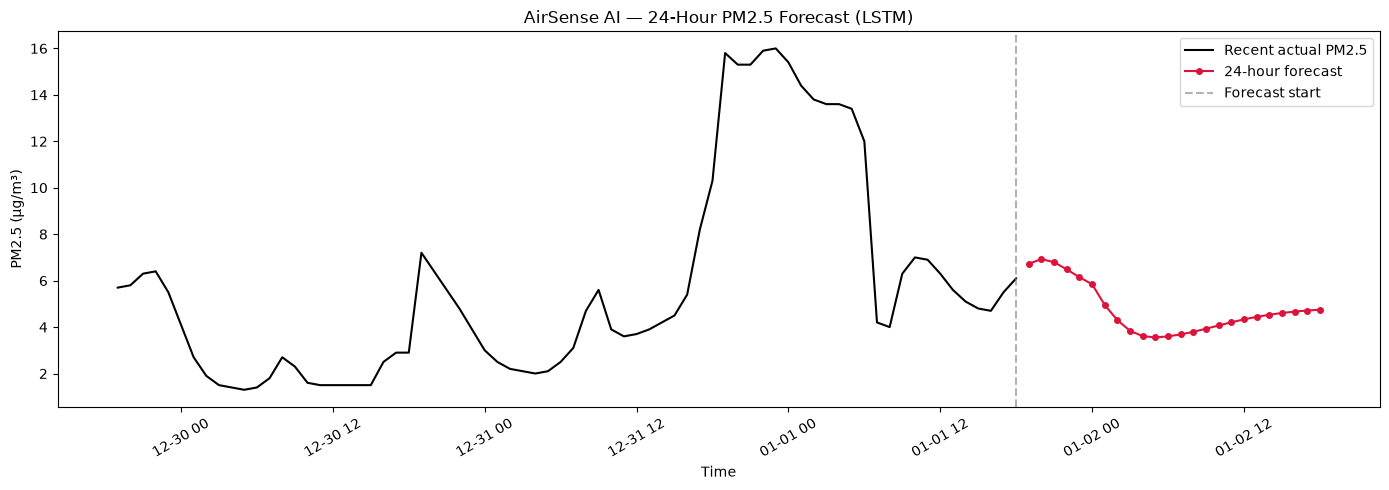

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))

recent_history = cube.tail(72)
ax.plot(recent_history['time'], recent_history['PM2.5'], label='Recent actual PM2.5', color='black')
ax.plot(forecast_times, forecast_values, label='24-hour forecast', color='crimson', marker='o', markersize=4)
ax.axvline(last_time, color='gray', linestyle='--', alpha=0.6, label='Forecast start')

ax.set_xlabel("Time")
ax.set_ylabel("PM2.5 (μg/m³)")
ax.set_title(f"AirSense AI — 24-Hour PM2.5 Forecast ({fresh_config['model_type']})")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Observation:** _(fill this in after running the cell above)_
Note whether the forecast looks plausible given the recent trend (a
reasonable continuation, not a wild jump), and if using LSTM/BiLSTM, note how
much the forecast quality degrades toward hour 24 — since weather is held
constant and PM2.5 is fed back into itself, error naturally compounds over
the 24-hour horizon. This is expected and worth mentioning in any writeup of
the project's limitations.

## 7. Final artifact checklist

Confirm everything the dashboard needs actually exists on disk before
moving on.

In [13]:
required_files = {
    "Best model (Keras)": MODELS_DIR / "best_model.keras",
    "Best model (pickle)": MODELS_DIR / "best_model.pkl",
    "Deployment config": MODELS_DIR / "deployment_config.pkl",
    "Model comparison table": MODELS_DIR / "model_comparison.csv",
    "Feature columns (Notebook 5)": MODELS_DIR / "feature_columns.pkl",
    "Scaler (Notebook 5)": MODELS_DIR / "scaler.pkl",
}

print(f"Winning model type: {winner_name}\n")
for label, path in required_files.items():
    status = "✅ exists" if path.exists() else "—  not present"
    # Only Keras OR pickle model file is expected to exist, not both
    print(f"{status:12} | {label}: {path.name}")

Winning model type: LSTM

✅ exists     | Best model (Keras): best_model.keras
—  not present | Best model (pickle): best_model.pkl
✅ exists     | Deployment config: deployment_config.pkl
✅ exists     | Model comparison table: model_comparison.csv
✅ exists     | Feature columns (Notebook 5): feature_columns.pkl
✅ exists     | Scaler (Notebook 5): scaler.pkl


**Note:** exactly one of `best_model.keras` / `best_model.pkl` should
exist (whichever matches the winning model type) — the other is expected to
be missing, that's normal, not an error.

## 8. Summary

At this point, everything the Streamlit dashboard needs is prepared and
verified:

- ✅ Identified the winning model from Notebook 7's comparison table
- ✅ Packaged model-specific artifacts (scaler + feature list for
  LSTM/BiLSTM; nothing extra needed for SARIMA/Persistence) into
  `deployment_config.pkl`
- ✅ Built a 24-hour forecast function tailored to the winning model type
- ✅ Ran a full fresh-from-disk sanity check — loaded artifacts exactly as
  the dashboard will, generated a real forecast, and visually confirmed it
  looks reasonable
- ✅ Verified all required files exist on disk

**Next step → Streamlit Dashboard (`app/app.py`):**
Build the 6-tab dashboard (Dashboard, Forecast, Environmental Signals, Model
Performance, What-If Simulation, AI Environmental Assistant) using
`deployment_config.pkl` and the forecast functions built here as the core
prediction engine.